# Comparação: Distribuição da Variável Alvo (Is Laundering)
## ANTES e DEPOIS da Técnica de Balanceamento RUS

Este notebook demonstra o impacto da técnica RUS (Random Under-Sampling) na distribuição da variável alvo.

## 1. Configuração e Importações

In [1]:
# Setup de paths
import sys
from pathlib import Path

notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    sys.path.insert(0, str(notebook_dir.parent))
else:
    sys.path.insert(0, str(notebook_dir))

from source.config import get_data_path

# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("✅ Bibliotecas importadas com sucesso!")

2026-02-02 08:58:02.246 | INFO     | source.config:<module>:77 - [CONFIG] PROJ_ROOT: C:\Users\win\Desktop\TCC\money_laundering
2026-02-02 08:58:02.249 | INFO     | source.config:<module>:78 - [CONFIG] Python executando de: c:\Users\win\Desktop\TCC\money_laundering\notebooks
✅ Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados de Treino

In [2]:
# Carregar dados de treino transformados
X_train = pd.read_csv(get_data_path('X_train.csv', 'processed'))
y_train = pd.read_csv(get_data_path('y_train.csv', 'processed')).squeeze()

print("="*80)
print("DADOS CARREGADOS")
print("="*80)
print(f"\n📊 X_train: {X_train.shape}")
print(f"📊 y_train: {y_train.shape}")
print(f"\n✅ Dados carregados com sucesso!")

DADOS CARREGADOS

📊 X_train: (2500119, 64)
📊 y_train: (2500119,)

✅ Dados carregados com sucesso!


## 3. Análise ANTES do Balanceamento RUS

In [3]:
# Contagem antes do balanceamento
counts_before = y_train.value_counts().sort_index()
total_before = len(y_train)

print("="*80)
print("DISTRIBUIÇÃO ANTES DO BALANCEAMENTO RUS")
print("="*80)
print(f"\nClasse 0 (Não Lavagem): {counts_before[0]:,} ({counts_before[0]/total_before*100:.2f}%)")
print(f"Classe 1 (Lavagem):     {counts_before[1]:,} ({counts_before[1]/total_before*100:.2f}%)")
print(f"\nTotal: {total_before:,}")
print(f"Razão de Desbalanceamento: {counts_before[0]/counts_before[1]:.2f}:1")

DISTRIBUIÇÃO ANTES DO BALANCEAMENTO RUS

Classe 0 (Não Lavagem): 2,498,945 (99.95%)
Classe 1 (Lavagem):     1,174 (0.05%)

Total: 2,500,119
Razão de Desbalanceamento: 2128.57:1


## 4. Aplicação da Técnica RUS (Random Under-Sampling)

In [4]:
# Aplicar RUS
print("="*80)
print("APLICANDO RANDOM UNDER-SAMPLING (RUS)")
print("="*80)

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"\n✅ RUS aplicado com sucesso!")
print(f"\n📊 X_train_rus: {X_train_rus.shape}")
print(f"📊 y_train_rus: {y_train_rus.shape}")

APLICANDO RANDOM UNDER-SAMPLING (RUS)

✅ RUS aplicado com sucesso!

📊 X_train_rus: (2348, 64)
📊 y_train_rus: (2348,)


## 5. Análise DEPOIS do Balanceamento RUS

In [5]:
# Contagem depois do balanceamento
counts_after = pd.Series(y_train_rus).value_counts().sort_index()
total_after = len(y_train_rus)

print("="*80)
print("DISTRIBUIÇÃO DEPOIS DO BALANCEAMENTO RUS")
print("="*80)
print(f"\nClasse 0 (Não Lavagem): {counts_after[0]:,} ({counts_after[0]/total_after*100:.2f}%)")
print(f"Classe 1 (Lavagem):     {counts_after[1]:,} ({counts_after[1]/total_after*100:.2f}%)")
print(f"\nTotal: {total_after:,}")
print(f"Razão de Balanceamento: {counts_after[0]/counts_after[1]:.2f}:1")

DISTRIBUIÇÃO DEPOIS DO BALANCEAMENTO RUS

Classe 0 (Não Lavagem): 1,174 (50.00%)
Classe 1 (Lavagem):     1,174 (50.00%)

Total: 2,348
Razão de Balanceamento: 1.00:1


## 6. GRÁFICO COMPARATIVO: Antes vs Depois do RUS

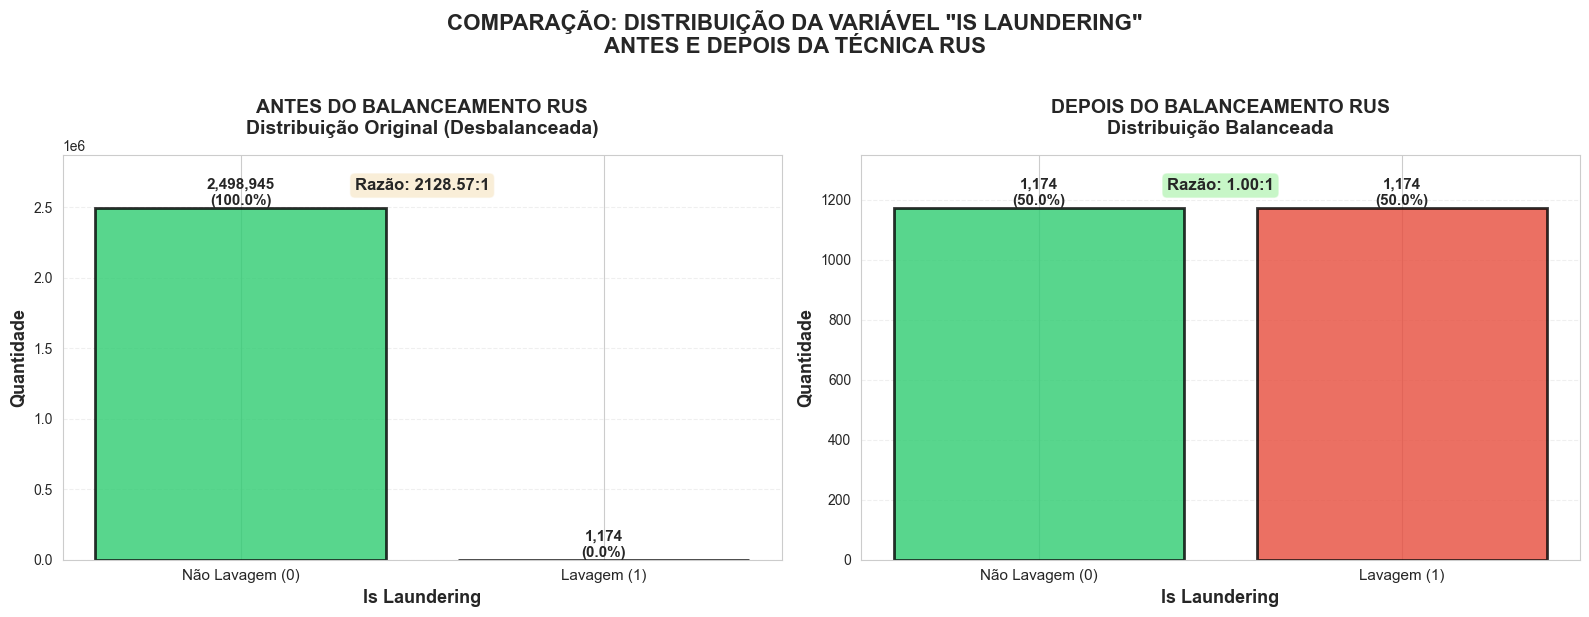


RESUMO DA COMPARAÇÃO

📊 ANTES:
   Total de amostras: 2,500,119
   Razão: 2128.57:1

📊 DEPOIS:
   Total de amostras: 2,348
   Razão: 1.00:1

📉 Redução de amostras: 2,497,771 (99.9%)

✅ Balanceamento aplicado com sucesso!


In [9]:
# Criar figura com dois subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cores
colors = ['#2ecc71', '#e74c3c']

# ========== GRÁFICO 1: ANTES DO RUS ==========
ax1 = axes[0]
bars1 = ax1.bar(counts_before.index, counts_before.values, 
                color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Adicionar rótulos nas barras
for bar in bars1:
    height = bar.get_height()
    percentage = (height / total_before) * 100
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xlabel('Is Laundering', fontsize=13, fontweight='bold')
ax1.set_ylabel('Quantidade', fontsize=13, fontweight='bold')
ax1.set_title('ANTES DO BALANCEAMENTO RUS\nDistribuição Original (Desbalanceada)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Não Lavagem (0)', 'Lavagem (1)'], fontsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(0, max(counts_before.values) * 1.15)

# Adicionar texto de razão
ratio_before = counts_before[0] / counts_before[1]
ax1.text(0.5, max(counts_before.values) * 1.05, 
         f'Razão: {ratio_before:.2f}:1',
         ha='center', fontsize=12, fontweight='bold', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ========== GRÁFICO 2: DEPOIS DO RUS ==========
ax2 = axes[1]
bars2 = ax2.bar(counts_after.index, counts_after.values, 
                color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Adicionar rótulos nas barras
for bar in bars2:
    height = bar.get_height()
    percentage = (height / total_after) * 100
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_xlabel('Is Laundering', fontsize=13, fontweight='bold')
ax2.set_ylabel('Quantidade', fontsize=13, fontweight='bold')
ax2.set_title('DEPOIS DO BALANCEAMENTO RUS\nDistribuição Balanceada', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Não Lavagem (0)', 'Lavagem (1)'], fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(0, max(counts_after.values) * 1.15)  # Escala ajustada para melhor visualização

# Adicionar texto de razão
ratio_after = counts_after[0] / counts_after[1]
ax2.text(0.5, max(counts_after.values) * 1.05, 
         f'Razão: {ratio_after:.2f}:1',
         ha='center', fontsize=12, fontweight='bold', 
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# Título geral
fig.suptitle('COMPARAÇÃO: DISTRIBUIÇÃO DA VARIÁVEL "IS LAUNDERING"\nANTES E DEPOIS DA TÉCNICA RUS', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("RESUMO DA COMPARAÇÃO")
print("="*80)
print(f"\n📊 ANTES:")
print(f"   Total de amostras: {total_before:,}")
print(f"   Razão: {ratio_before:.2f}:1")
print(f"\n📊 DEPOIS:")
print(f"   Total de amostras: {total_after:,}")
print(f"   Razão: {ratio_after:.2f}:1")
print(f"\n📉 Redução de amostras: {total_before - total_after:,} ({(total_before - total_after)/total_before*100:.1f}%)")
print(f"\n✅ Balanceamento aplicado com sucesso!")

## 7. Gráfico de Pizza Comparativo

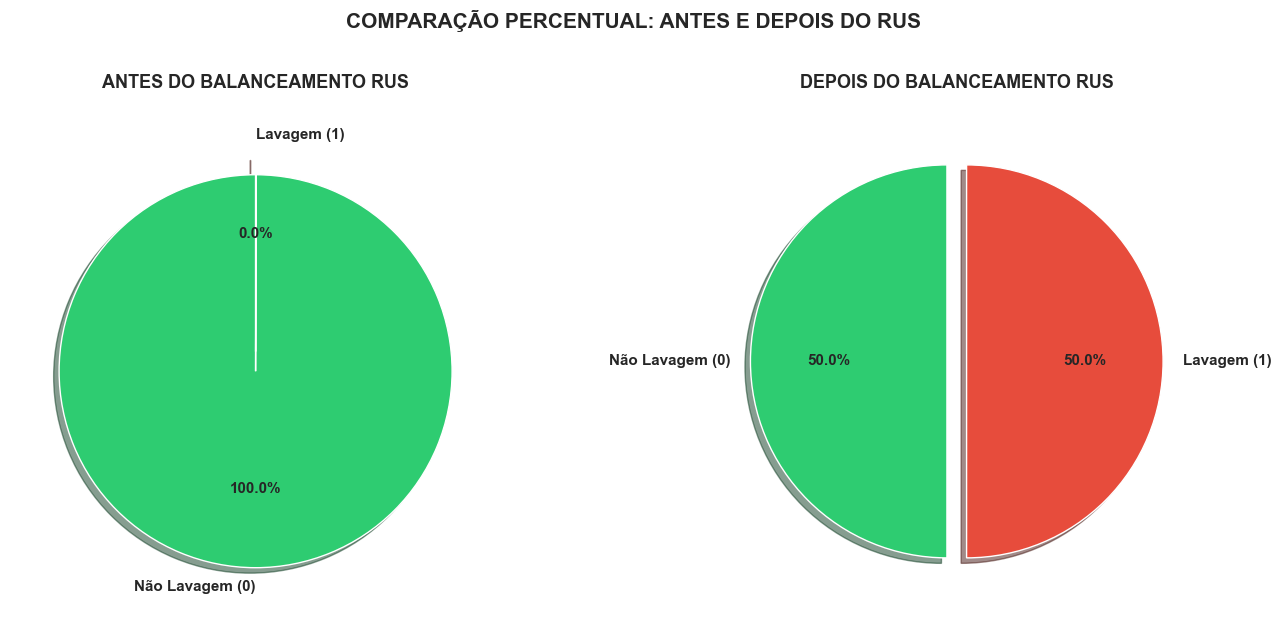

In [7]:
# Criar figura com dois gráficos de pizza lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Cores e labels
colors_pie = ['#2ecc71', '#e74c3c']
labels = ['Não Lavagem (0)', 'Lavagem (1)']
explode = (0.05, 0.05)

# ========== PIZZA 1: ANTES DO RUS ==========
ax1 = axes[0]
wedges1, texts1, autotexts1 = ax1.pie(counts_before.values, 
                                       labels=labels, 
                                       autopct='%1.1f%%',
                                       colors=colors_pie, 
                                       explode=explode,
                                       shadow=True, 
                                       startangle=90,
                                       textprops={'fontsize': 11, 'fontweight': 'bold'})

ax1.set_title('ANTES DO BALANCEAMENTO RUS', 
              fontsize=13, fontweight='bold', pad=20)

# ========== PIZZA 2: DEPOIS DO RUS ==========
ax2 = axes[1]
wedges2, texts2, autotexts2 = ax2.pie(counts_after.values, 
                                       labels=labels, 
                                       autopct='%1.1f%%',
                                       colors=colors_pie, 
                                       explode=explode,
                                       shadow=True, 
                                       startangle=90,
                                       textprops={'fontsize': 11, 'fontweight': 'bold'})

ax2.set_title('DEPOIS DO BALANCEAMENTO RUS', 
              fontsize=13, fontweight='bold', pad=20)

# Título geral
fig.suptitle('COMPARAÇÃO PERCENTUAL: ANTES E DEPOIS DO RUS', 
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## 8. Estatísticas Detalhadas

In [8]:
# Criar tabela comparativa
comparison_df = pd.DataFrame({
    'Métrica': [
        'Total de Amostras',
        'Classe 0 (Não Lavagem)',
        'Classe 1 (Lavagem)',
        'Percentual Classe 0',
        'Percentual Classe 1',
        'Razão de Desbalanceamento'
    ],
    'ANTES DO RUS': [
        f"{total_before:,}",
        f"{counts_before[0]:,}",
        f"{counts_before[1]:,}",
        f"{counts_before[0]/total_before*100:.2f}%",
        f"{counts_before[1]/total_before*100:.2f}%",
        f"{ratio_before:.2f}:1"
    ],
    'DEPOIS DO RUS': [
        f"{total_after:,}",
        f"{counts_after[0]:,}",
        f"{counts_after[1]:,}",
        f"{counts_after[0]/total_after*100:.2f}%",
        f"{counts_after[1]/total_after*100:.2f}%",
        f"{ratio_after:.2f}:1"
    ]
})

print("="*80)
print("TABELA COMPARATIVA DETALHADA")
print("="*80)
print()
display(comparison_df)

print("\n" + "="*80)
print("CONCLUSÃO")
print("="*80)
print(f"""
✅ A técnica RUS (Random Under-Sampling) foi aplicada com sucesso!

📊 Impacto:
   • Redução de {total_before - total_after:,} amostras ({(total_before - total_after)/total_before*100:.1f}%)
   • Balanceamento perfeito: razão de {ratio_after:.2f}:1
   • Manteve todas as {counts_after[1]:,} amostras da classe minoritária (Lavagem)
   • Reduziu a classe majoritária (Não Lavagem) de {counts_before[0]:,} para {counts_after[0]:,}

💡 Benefícios:
   • Melhora a capacidade do modelo de aprender padrões da classe minoritária
   • Reduz o viés em direção à classe majoritária
   • Melhora métricas como Recall e F1-Score para a classe minoritária
""")

TABELA COMPARATIVA DETALHADA



,Métrica,ANTES DO RUS,DEPOIS DO RUS
0,Total de Amostras,"2,500,119","2,348"
1,Classe 0 (Não Lavagem),"2,498,945","1,174"
2,Classe 1 (Lavagem),"1,174","1,174"
3,Percentual Classe 0,99.95%,50.00%
4,Percentual Classe 1,0.05%,50.00%
5,Razão de Desbalanceamento,2128.57:1,1.00:1



CONCLUSÃO

✅ A técnica RUS (Random Under-Sampling) foi aplicada com sucesso!

📊 Impacto:
   • Redução de 2,497,771 amostras (99.9%)
   • Balanceamento perfeito: razão de 1.00:1
   • Manteve todas as 1,174 amostras da classe minoritária (Lavagem)
   • Reduziu a classe majoritária (Não Lavagem) de 2,498,945 para 1,174

💡 Benefícios:
   • Melhora a capacidade do modelo de aprender padrões da classe minoritária
   • Reduz o viés em direção à classe majoritária
   • Melhora métricas como Recall e F1-Score para a classe minoritária

